In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
print("Columns:", df.columns.tolist())
print("\nDataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nFirst Five Rows:")
display(df.head())

Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Dataset Shape: (5572, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate Rows: 403

First Five Rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df = df[["v1", "v2"]].copy()
df.columns = ["label", "message"]
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Remove rows with missing values and duplicate messages
df = df.dropna(subset=["label", "message"]).drop_duplicates().reset_index(drop=True)

# Standardize label text before encoding
df["label"] = df["label"].astype(str).str.strip().str.lower()

# Encode ham = 0 and spam = 1
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Remove unexpected labels, if any
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

print("Cleaned Dataset Shape:", df.shape)
print("\nClass Counts:")
print(df["label"].value_counts())
df.head()

Cleaned Dataset Shape: (5169, 2)

Class Counts:
label
0    4516
1     653
Name: count, dtype: int64


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


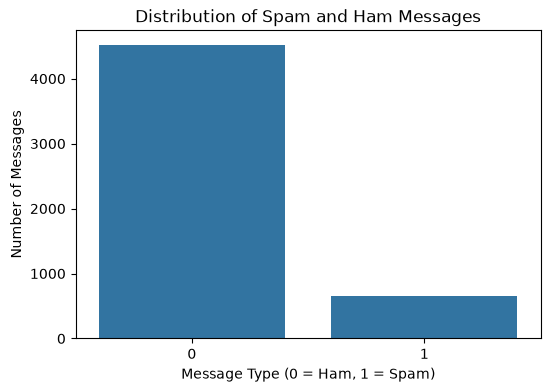

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df)
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Messages")
plt.show()

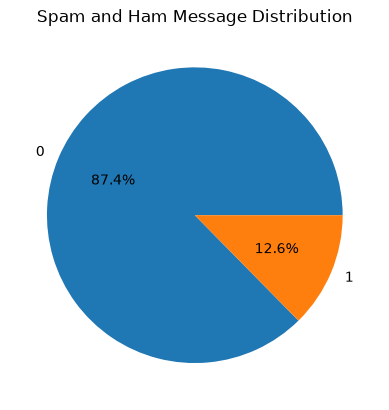

In [7]:
df["label"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Spam and Ham Message Distribution")
plt.ylabel("")
plt.show()

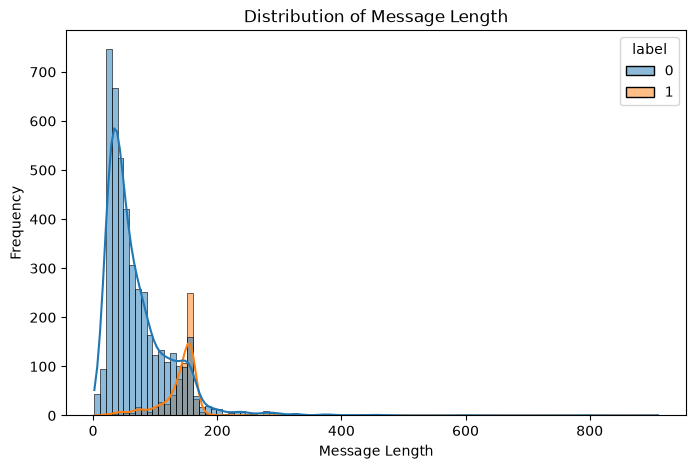

In [8]:
df["message_length"] = df["message"].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="message_length", hue="label", kde=True)
plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

In [11]:
X = df["message"]
y = df["label"]

In [12]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4135
Testing samples: 1034


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

# Fit only on the training data to avoid data leakage
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 2000)
Testing TF-IDF shape: (1034, 2000)


In [14]:
from sklearn.decomposition import TruncatedSVD

# Keep n_components valid even if the dataset/vectorizer has fewer features
n_components = min(100, X_train_tfidf.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

X_train_reduced = svd.fit_transform(X_train_tfidf)
X_test_reduced = svd.transform(X_test_tfidf)

print("Reduced training shape:", X_train_reduced.shape)
print("Reduced testing shape:", X_test_reduced.shape)

Reduced training shape: (4135, 100)
Reduced testing shape: (1034, 100)


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Dictionary avoids duplicate rows if a model cell is run again.
results = {}

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    print("\n" + "=" * 60)
    print("MODEL:", model_name)
    print("=" * 60)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    results[model_name] = {
        "Algorithm": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return y_pred


MODEL: Logistic Regression
Accuracy : 0.9603
Precision: 0.9787
Recall   : 0.7023
F1 Score : 0.8178

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.98      0.70      0.82       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034

Confusion Matrix:
[[901   2]
 [ 39  92]]


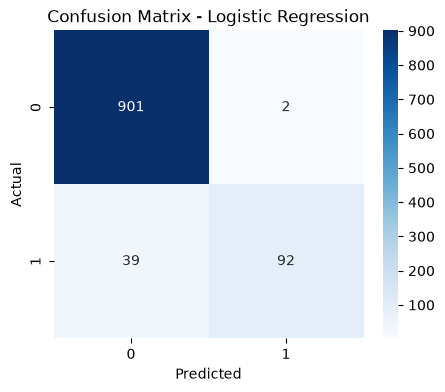

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)


MODEL: Extra Trees Classifier
Accuracy : 0.9797
Precision: 0.9741
Recall   : 0.8626
F1 Score : 0.915

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.86      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix:
[[900   3]
 [ 18 113]]


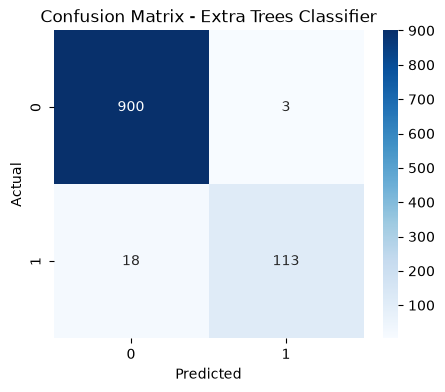

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [17]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

evaluate_model(
    "Extra Trees Classifier",
    extra_trees_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)


MODEL: Linear Discriminant Analysis
Accuracy : 0.9652
Precision: 0.9612
Recall   : 0.7557
F1 Score : 0.8462

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       0.96      0.76      0.85       131

    accuracy                           0.97      1034
   macro avg       0.96      0.88      0.91      1034
weighted avg       0.97      0.97      0.96      1034

Confusion Matrix:
[[899   4]
 [ 32  99]]


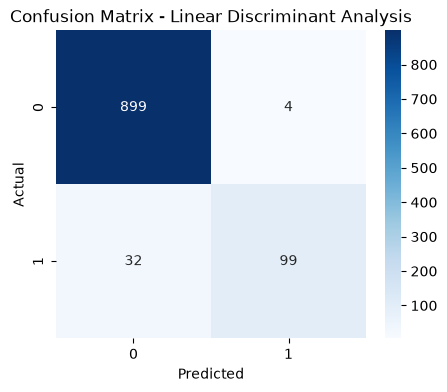

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

evaluate_model(
    "Linear Discriminant Analysis",
    lda_model,
    X_train_reduced,
    X_test_reduced,
    y_train,
    y_test
)


MODEL: Quadratic Discriminant Analysis
Accuracy : 0.8733
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       903
           1       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weighted avg       0.76      0.87      0.81      1034

Confusion Matrix:
[[903   0]
 [131   0]]


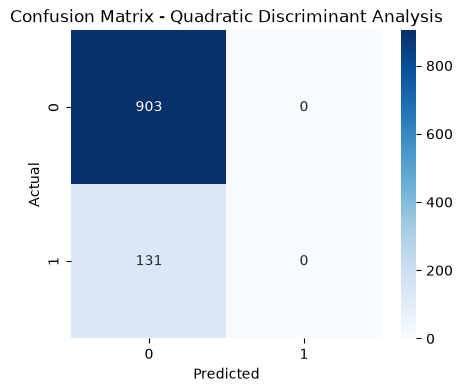

array([0, 0, 0, ..., 0, 0, 0], shape=(1034,))

In [19]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda_model = QuadraticDiscriminantAnalysis(reg_param=0.1)

evaluate_model(
    "Quadratic Discriminant Analysis",
    qda_model,
    X_train_reduced,
    X_test_reduced,
    y_train,
    y_test
)


MODEL: MLP Classifier
Accuracy : 0.9787
Precision: 0.9431
Recall   : 0.8855
F1 Score : 0.9134

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.94      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix:
[[896   7]
 [ 15 116]]


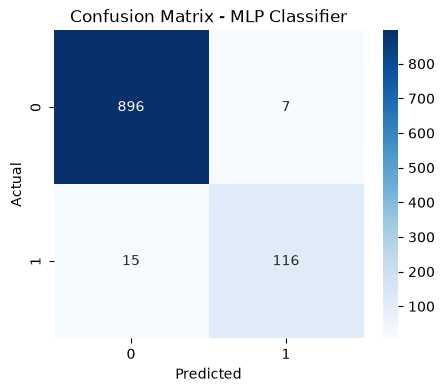

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [20]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=1000,
    random_state=42
)

evaluate_model(
    "MLP Classifier",
    mlp_model,
    X_train_reduced,
    X_test_reduced,
    y_train,
    y_test
)

In [21]:
results_df = pd.DataFrame(results.values()).reset_index(drop=True)
results_df


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.960348,0.978723,0.702290,0.817778
1,Extra Trees Classifier,0.979691,0.974138,0.862595,0.914980
2,Linear Discriminant Analysis,0.965184,0.961165,0.755725,0.846154
3,Quadratic Discriminant Analysis,0.873308,0.000000,0.000000,0.000000
4,MLP Classifier,0.978723,0.943089,0.885496,0.913386


In [22]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("BEST PERFORMING ALGORITHM:")
print(best_model)

BEST PERFORMING ALGORITHM:
Algorithm    Extra Trees Classifier
Accuracy                   0.979691
Precision                  0.974138
Recall                     0.862595
F1 Score                    0.91498
Name: 1, dtype: object


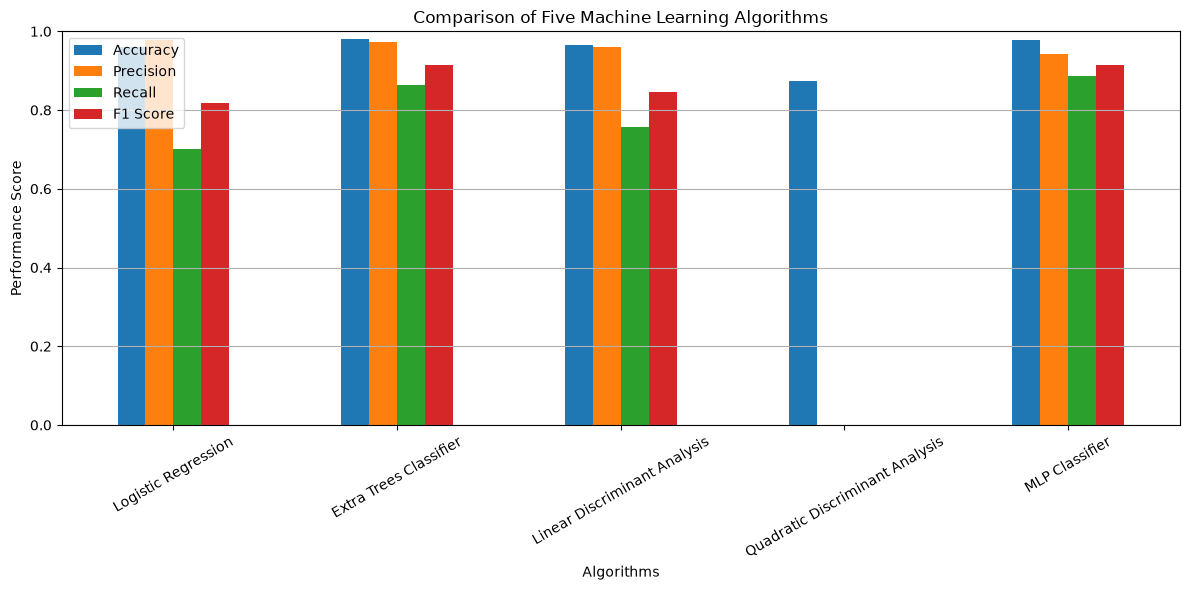

In [23]:
results_df.plot(
    x="Algorithm",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Five Machine Learning Algorithms")
plt.xlabel("Algorithms")
plt.ylabel("Performance Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()